In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv("titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
df.shape

(891, 12)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [92]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Check Duplicate Values

In [93]:
df.duplicated().sum()

np.int64(0)

### Missing Values Check

In [94]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Fill Missing Values

In [95]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df = df.drop('Cabin', axis=1)

In [96]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Histograms

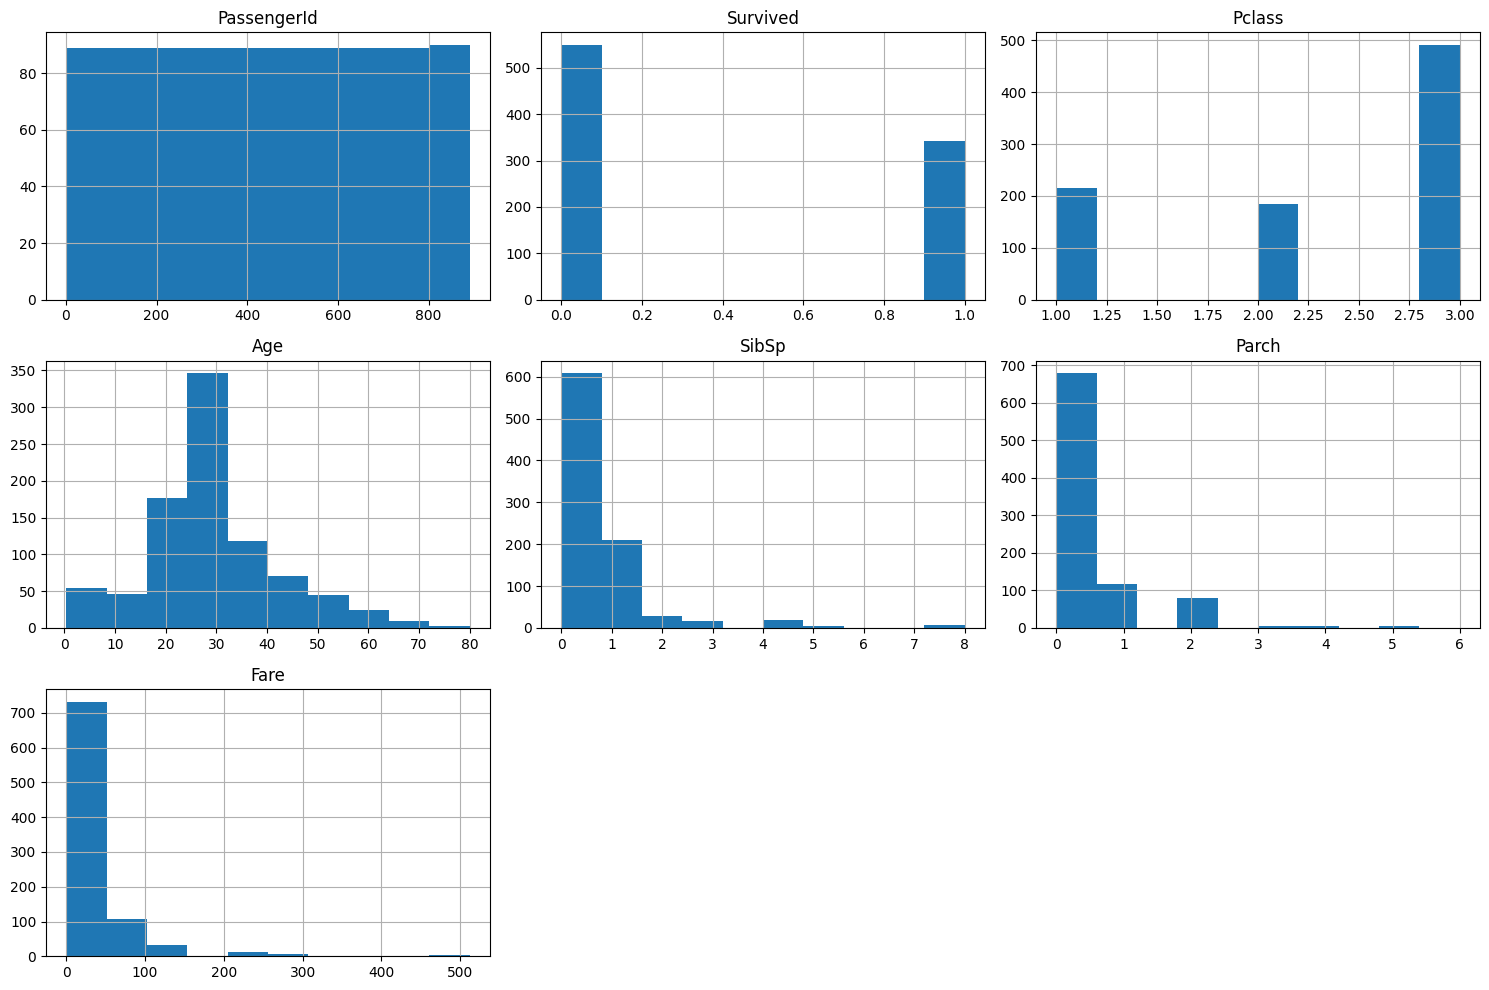

In [97]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

### Box Plots (Outliers Check)

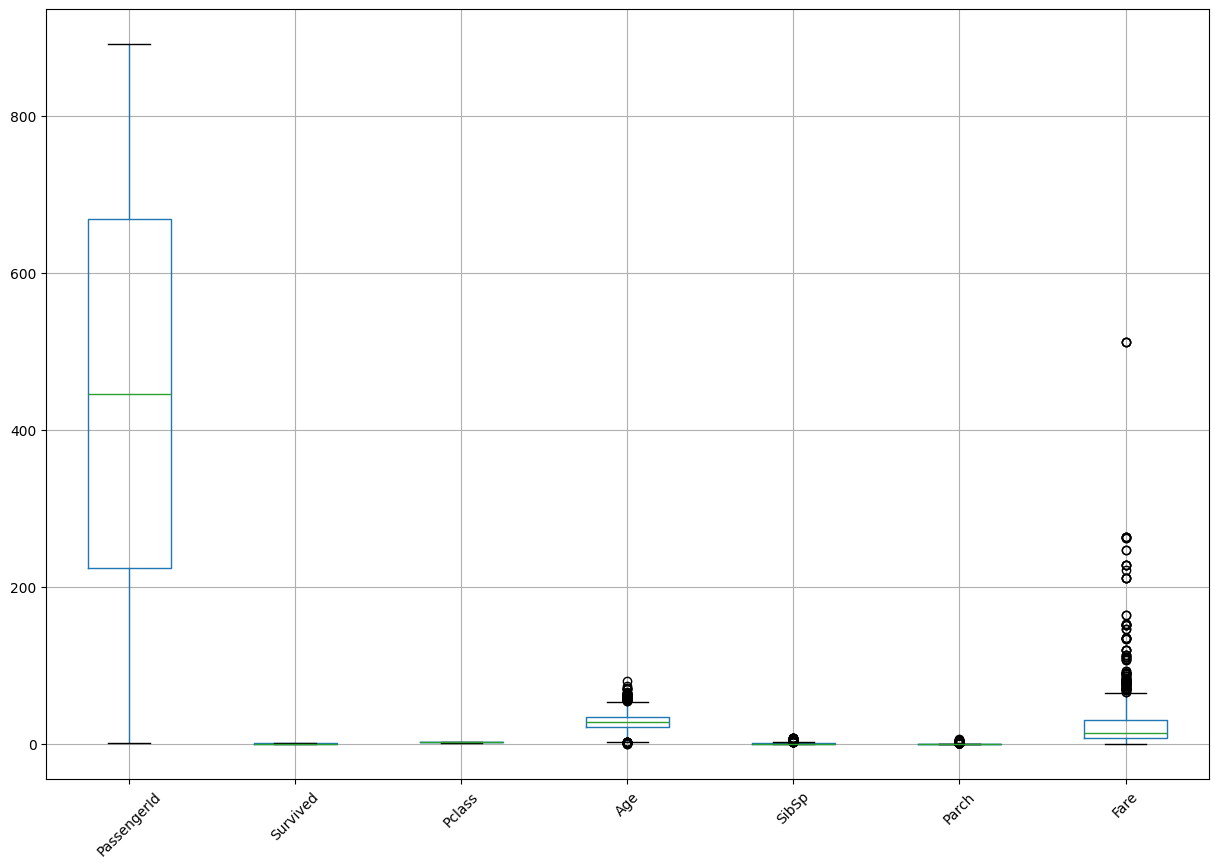

In [98]:
plt.figure(figsize=(15,10))

df.boxplot()

plt.xticks(rotation=45)

plt.show()

### Outlier Treatment IQR Method

In [99]:
Q1 = df.select_dtypes(include=np.number).quantile(0.25)

Q3 = df.select_dtypes(include=np.number).quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
      (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)
]

df.shape

(577, 11)

### Scatter Plot (Age vs Fare)

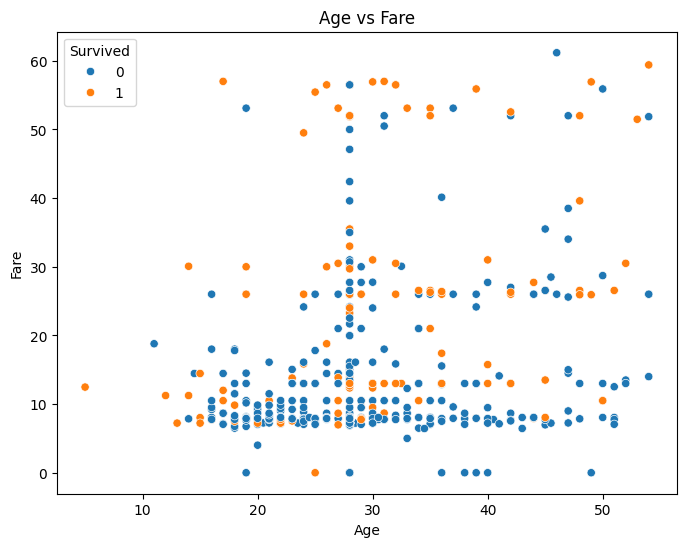

In [100]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survived',
    data=df
)

plt.title("Age vs Fare")
plt.show()

### Bar Plot (Survival by Sex)

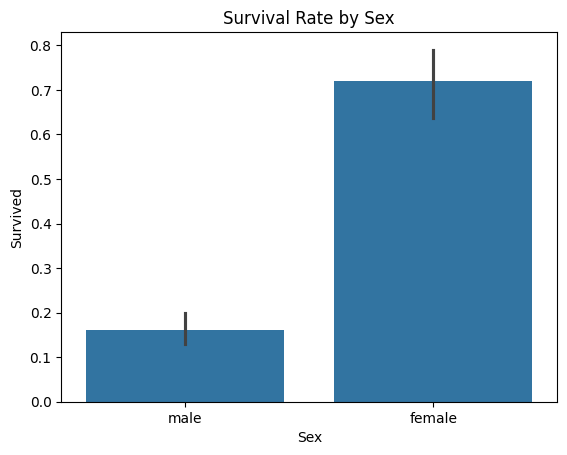

In [101]:
sns.barplot(
    x='Sex',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Sex")

plt.show()

### Correlation Matrix

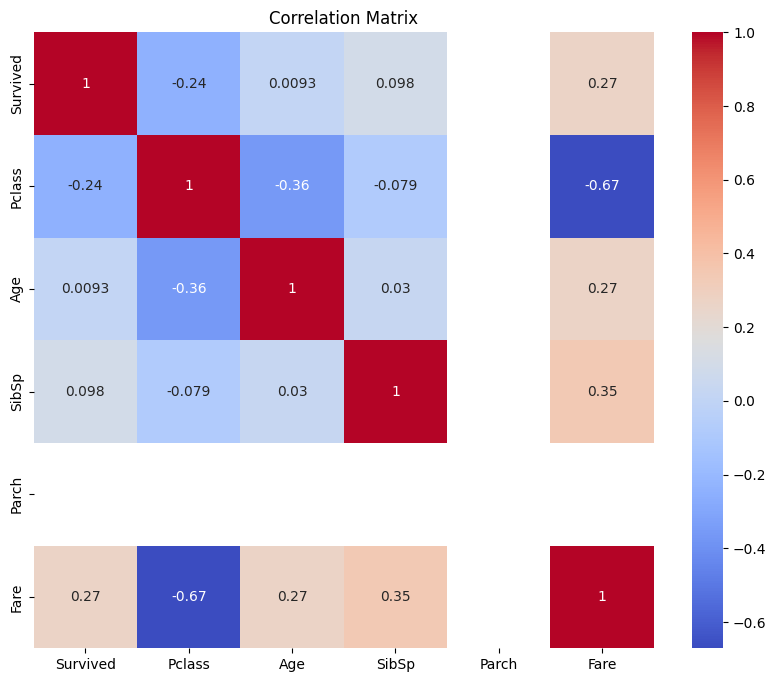

In [122]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

### Drop Unnecessary Columns

###### Name, Ticket, and PassengerId are not useful for prediction.

In [102]:
df = df.drop(
    ['PassengerId', 'Name', 'Ticket'],
    axis=1
)

### Encode Categorical Variables

In [103]:
df = pd.get_dummies(
    df,
    drop_first=True
)

### Define Features and Target

In [104]:
X = df.drop('Survived', axis=1)

y = df['Survived']

### Train-Test Split

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(461, 8)
(116, 8)


### Import Evaluation Metrics

In [106]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

### Build LightGBM Model

In [107]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### LightGBM Prediction

In [108]:
lgbm_pred = lgbm_model.predict(X_test)

### Evaluate LightGBM Model

In [109]:
print("Accuracy:",
      accuracy_score(y_test, lgbm_pred))

print("Precision:",
      precision_score(y_test,
                      lgbm_pred))

print("Recall:",
      recall_score(y_test,
                   lgbm_pred))

print("F1 Score:",
      f1_score(y_test,
               lgbm_pred))

print(classification_report(y_test, lgbm_pred))

Accuracy: 0.8362068965517241
Precision: 0.6785714285714286
Recall: 0.6551724137931034
F1 Score: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        87
           1       0.68      0.66      0.67        29

    accuracy                           0.84       116
   macro avg       0.78      0.78      0.78       116
weighted avg       0.83      0.84      0.84       116



### Build XGBoost Model

In [110]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### XGBoost Prediction

In [111]:
xgb_pred = xgb_model.predict(X_test)

### Evaluate XGBoost Model

In [112]:
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test,
                      xgb_pred))

print("Recall:",
      recall_score(y_test,
                   xgb_pred))

print("F1 Score:",
      f1_score(y_test,
               xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy: 0.8362068965517241
Precision: 0.6785714285714286
Recall: 0.6551724137931034
F1 Score: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        87
           1       0.68      0.66      0.67        29

    accuracy                           0.84       116
   macro avg       0.78      0.78      0.78       116
weighted avg       0.83      0.84      0.84       116



### Cross Validation for LightGBM

In [113]:
from sklearn.model_selection import cross_val_score

lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm_cv = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=5
)

print("LightGBM CV Score:", lgbm_cv.mean())

LightGBM CV Score: 0.8007946026986505


### Cross Validation for XGBoost

In [114]:
xgb_cv = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5
)

print("XGBoost CV Score:", xgb_cv.mean())

XGBoost CV Score: 0.8025187406296851


### Hyperparameter Tuning for LightGBM

In [115]:
from sklearn.model_selection import GridSearchCV

lgbm_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(
        random_state=42,
        verbose=-1
    ),
    param_grid=lgbm_params,
    cv=5
)

lgbm_grid.fit(X_train, y_train)

print(lgbm_grid.best_params_)

{'max_depth': 5, 'n_estimators': 50}


### Train Best LightGBM Model

In [116]:
best_lgbm = lgbm_grid.best_estimator_

best_lgbm.set_params(verbose=-1)

best_lgbm.fit(X_train, y_train)

best_lgbm_pred = best_lgbm.predict(X_test)

### Evaluate Tuned LightGBM Model

In [117]:
print("Accuracy:",
      accuracy_score(y_test, best_lgbm_pred))

print("Precision:",
      precision_score(y_test,
                      best_lgbm_pred))

print("Recall:",
      recall_score(y_test,
                   best_lgbm_pred))

print("F1 Score:",
      f1_score(y_test,
               best_lgbm_pred))

Accuracy: 0.8620689655172413
Precision: 0.782608695652174
Recall: 0.6206896551724138
F1 Score: 0.6923076923076923


### Hyperparameter Tuning for XGBoost

In [118]:
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=xgb_params,
    cv=5
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)

{'max_depth': 3, 'n_estimators': 100}


### Train Best XGBoost Model

In [119]:
best_xgb = xgb_grid.best_estimator_

best_xgb.fit(X_train, y_train)

best_xgb_pred = best_xgb.predict(X_test)

### Evaluate Tuned XGBoost Model

In [120]:
print("Accuracy:",
      accuracy_score(y_test, best_xgb_pred))

print("Precision:",
      precision_score(y_test,
                      best_xgb_pred))

print("Recall:",
      recall_score(y_test,
                   best_xgb_pred))

print("F1 Score:",
      f1_score(y_test,
               best_xgb_pred))

Accuracy: 0.8362068965517241
Precision: 0.6785714285714286
Recall: 0.6551724137931034
F1 Score: 0.6666666666666666


### Comparative Analysis Table

In [121]:
comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    
    'Accuracy': [
        accuracy_score(y_test, best_lgbm_pred),
        accuracy_score(y_test, best_xgb_pred)
    ],
    
    'Precision': [
        precision_score(y_test, best_lgbm_pred),
        precision_score(y_test, best_xgb_pred)
    ],
    
    'Recall': [
        recall_score(y_test, best_lgbm_pred),
        recall_score(y_test, best_xgb_pred)
    ],
    
    'F1 Score': [
        f1_score(y_test, best_lgbm_pred),
        f1_score(y_test, best_xgb_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.862069,0.782609,0.620690,0.692308
1,XGBoost,0.836207,0.678571,0.655172,0.666667


### Visualize Model Comparison

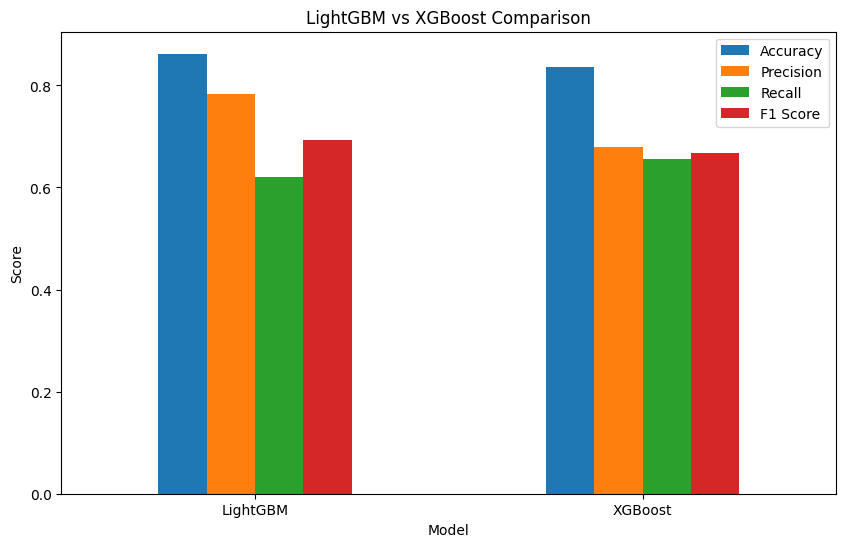

In [123]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("LightGBM vs XGBoost Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

## Comparative Analysis Report: LightGBM vs XGBoost on Titanic Dataset

#### Objective

###### The objective of this analysis was to compare the performance of LightGBM and XGBoost algorithms on the Titanic survival prediction dataset.

#### Exploratory Data Analysis

The dataset was explored using histograms, box plots, scatter plots, and bar plots. Missing values were identified in the Age, Cabin, and Embarked columns. The Cabin column contained a large number of missing values and was removed. Missing values in Age and Embarked were handled using median and mode imputation.

#### Data Preprocessing

###### Categorical variables were encoded using one-hot encoding. Unnecessary columns such as PassengerId, Name, and Ticket were removed. Outliers were handled using the IQR method.

#### Model Building

###### Both LightGBM and XGBoost models were trained using the processed dataset. Evaluation metrics including Accuracy, Precision, Recall, and F1-score were used to measure performance.

#### Hyperparameter Tuning

###### GridSearchCV was applied to optimize important hyperparameters such as:

###### * n_estimators
###### * max_depth

###### Cross-validation was also performed to improve model reliability.

#### Comparative Analysis

###### The comparison showed that both models performed well on the Titanic dataset. LightGBM provided faster training and efficient memory usage, while XGBoost demonstrated strong predictive performance and robustness.

#### Strengths of LightGBM

###### * Faster training speed
###### * Efficient for large datasets
###### * Lower memory consumption

#### Strengths of XGBoost

###### * Strong predictive accuracy
###### * Better handling of complex patterns
###### * Robust regularization support

#### Conclusion

###### Both LightGBM and XGBoost are powerful boosting algorithms for classification problems. The final model performance depends on the dataset characteristics and parameter tuning. In this analysis, both algorithms achieved strong classification performance on the Titanic dataset.
